# 🏨 Atlantic Haven Hotels — Prédiction d'annulation de réservation
### Hackathon ML & Data Science — M1 ISPM

**Objectif :** prédire `reservation_annulee` (0 = maintenue, 1 = annulée), fournir une probabilité et une décision binaire, et maximiser le **F1-score** sur la classe « annulation », tout en respectant l'ordre temporel des données.

---
## 📌 ÉTAPE 1 : EDA (Analyse Exploratoire des Données) & Préparation Initiale

### 1.1 Setup & Configuration de l'environnement

In [7]:
# --- ÉTAPE 1 : Imports et configuration globale ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# Graine aléatoire fixée pour la reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

### 1.2 Chargement des données

In [9]:
# --- ÉTAPE 1 : Chargement des jeux de données ---
TRAIN_PATH = "reservations_train.csv"
TEST_PATH  = "reservations_test.csv"
DICT_PATH  = "data_dictionary.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DICT_PATH)

print(f"Forme du jeu de Train : {df_train.shape}")
print(f"Forme du jeu de Test  : {df_test.shape}")
df_train.head()

Forme du jeu de Train : (8000, 34)
Forme du jeu de Test  : (2000, 33)


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


### 1.3 Inspection du dictionnaire des variables

In [10]:
# --- ÉTAPE 1 : Affichage du dictionnaire des données ---
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


### 1.4 Nettoyage et harmonisation des types de données

In [11]:
# --- ÉTAPE 1 : Correction des types de colonnes (Dates & Binaires) ---
def fix_data_types(df):
    df = df.copy()
    # Conversion des colonnes de dates
    df['date_reservation'] = pd.to_datetime(df['date_reservation'])
    df['date_arrivee'] = pd.to_datetime(df['date_arrivee'])

    # Harmonisation de la colonne binaire 'tarif_remboursable'
    if df['tarif_remboursable'].dtype == 'object':
        df['tarif_remboursable'] = df['tarif_remboursable'].astype(str).str.lower().map({
            'oui': 1, 'non': 0, 'true': 1, 'false': 0, '1': 1, '0': 0
        }).fillna(0).astype(int)

    return df

df_train = fix_data_types(df_train)
df_test = fix_data_types(df_test)

print("✅ Dates et types binaires corrigés avec succès !")

✅ Dates et types binaires corrigés avec succès !


### 1.5 Audit des valeurs manquantes

In [12]:
# --- ÉTAPE 1 : Bilan des valeurs manquantes ---
print("--- VALEURS MANQUANTES (TRAIN) ---")
missing_train = df_train.isnull().sum()
print(missing_train[missing_train > 0])

print("\n--- VALEURS MANQUANTES (TEST) ---")
missing_test = df_test.isnull().sum()
print(missing_test[missing_test > 0])

--- VALEURS MANQUANTES (TRAIN) ---
marche_origine          191
enfants                 355
prix_moyen_nuit_eur     193
demandes_speciales      157
agent_id               3354
dtype: int64

--- VALEURS MANQUANTES (TEST) ---
marche_origine          52
enfants                 88
prix_moyen_nuit_eur     34
demandes_speciales      29
agent_id               831
dtype: int64


### 1.6 Imputation métier intelligente

In [13]:
# --- ÉTAPE 1 : Traitement métier des valeurs manquantes ---
def process_missing_values(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()

    # 1. agent_id : NaN correspond à une réservation sans agence (Direct)
    train['agent_id'] = train['agent_id'].fillna('Direct')
    test['agent_id'] = test['agent_id'].fillna('Direct')

    train['est_reservation_directe'] = (train['agent_id'] == 'Direct').astype(int)
    test['est_reservation_directe'] = (test['agent_id'] == 'Direct').astype(int)

    # 2. enfants & demandes_speciales : NaN = 0
    train['enfants'] = train['enfants'].fillna(0).astype(int)
    test['enfants'] = test['enfants'].fillna(0).astype(int)

    train['demandes_speciales'] = train['demandes_speciales'].fillna(0).astype(int)
    test['demandes_speciales'] = test['demandes_speciales'].fillna(0).astype(int)

    # 3. marche_origine : Imputation par le mode sur le Train
    mode_marche = train['marche_origine'].mode()[0]
    train['marche_origine'] = train['marche_origine'].fillna(mode_marche)
    test['marche_origine'] = test['marche_origine'].fillna(mode_marche)

    # 4. prix_moyen_nuit_eur : Médiane par catégorie d'hôtel (calculée sur le Train uniquement)
    medians_par_categorie = train.groupby('categorie_hotel')['prix_moyen_nuit_eur'].median()

    train['prix_moyen_nuit_eur'] = train['prix_moyen_nuit_eur'].fillna(
        train['categorie_hotel'].map(medians_par_categorie)
    )
    test['prix_moyen_nuit_eur'] = test['prix_moyen_nuit_eur'].fillna(
        test['categorie_hotel'].map(medians_par_categorie)
    )

    return train, test

# Exécution
df_train_clean, df_test_clean = process_missing_values(df_train, df_test)

### 1.7 Validation du nettoyage

In [14]:
# --- ÉTAPE 1 : Vérification qu'il ne reste aucun NaN ---
print("Valeurs manquantes restantes dans Train Clean :", df_train_clean.isnull().sum().sum())
print("Valeurs manquantes restantes dans Test Clean  :", df_test_clean.isnull().sum().sum())

Valeurs manquantes restantes dans Train Clean : 0
Valeurs manquantes restantes dans Test Clean  : 0


### 1.8 Analyse Visuelle de l'EDA & Split Temporel de Validation

/tmp/ipykernel_701/2168135992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='type_acompte', y='reservation_annulee', ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_701/2168135992.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='tarif_remboursable', y='reservation_annulee', ax=axes[0, 1], palette='Oranges_r')
/tmp/ipykernel_701/2168135992.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='reservation_annulee', y='annulations_passees', ax=axes[1, 1], palette=['#4f8c48', '#e77a2

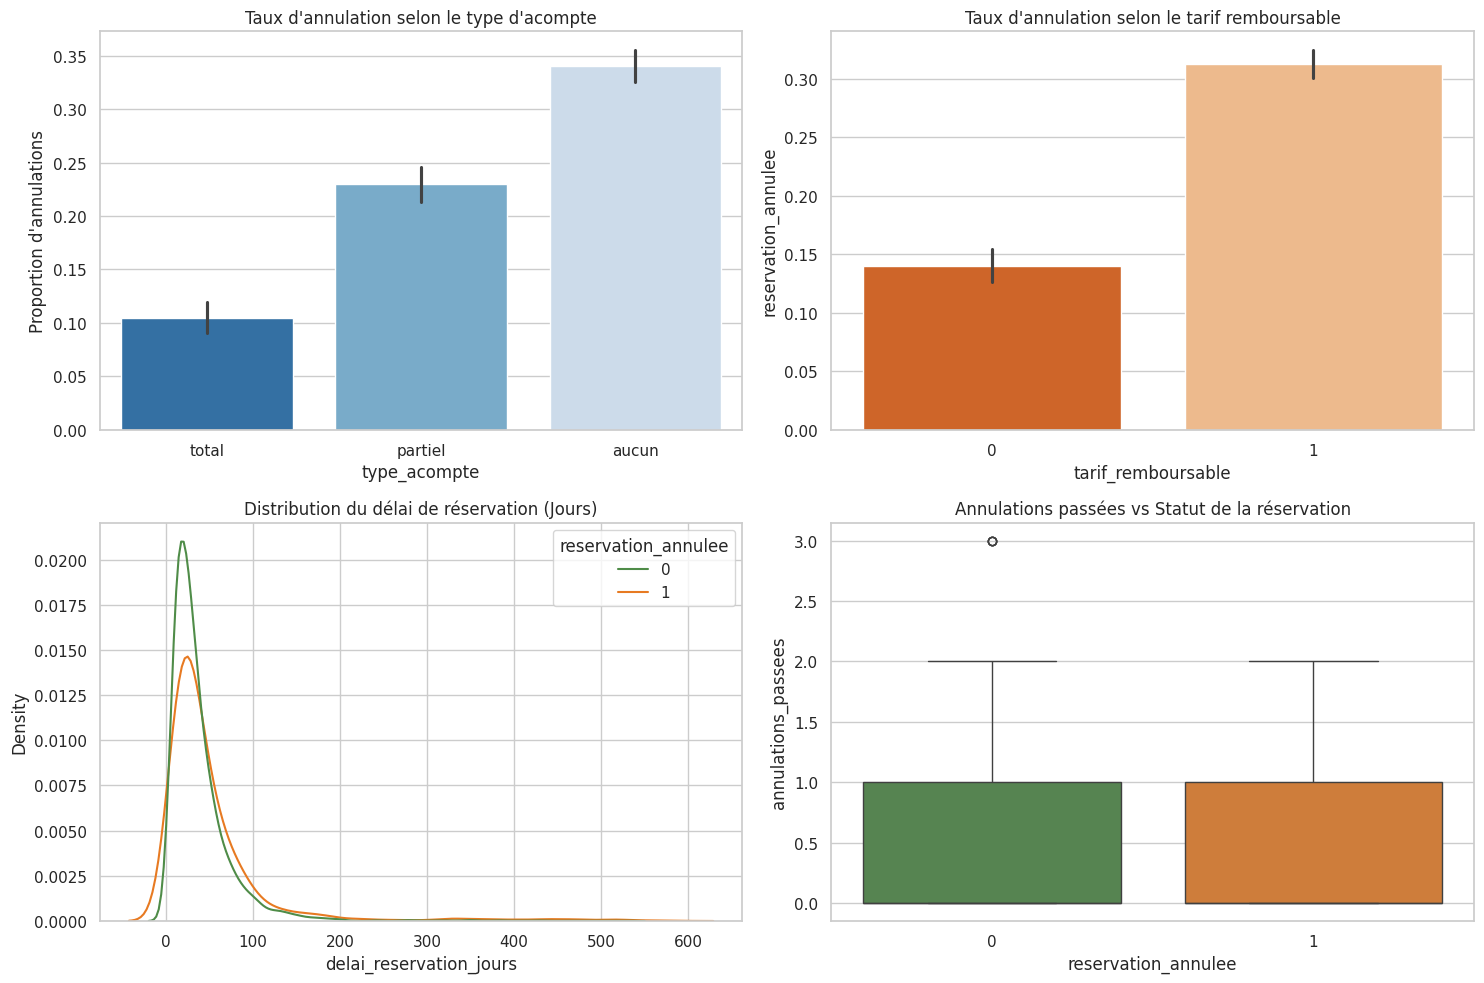


✅ --- SPLIT TEMPOREL EFFECTUÉ ---
Train Split : 6400 lignes (2023-01-01 à 2024-11-28)
Val Split   : 1600 lignes (2024-11-28 à 2025-05-24)


In [15]:
# --- ÉTAPE 1 : Visualisations EDA & Validation Temporelle ---
df_train = df_train_clean.copy()
df_test = df_test_clean.copy()

# Visualisation des facteurs clés d'annulation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Taux d'annulation par type d'acompte
sns.barplot(data=df_train, x='type_acompte', y='reservation_annulee', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title("Taux d'annulation selon le type d'acompte")
axes[0, 0].set_ylabel("Proportion d'annulations")

# 2. Taux d'annulation selon le tarif remboursable
sns.barplot(data=df_train, x='tarif_remboursable', y='reservation_annulee', ax=axes[0, 1], palette='Oranges_r')
axes[0, 1].set_title("Taux d'annulation selon le tarif remboursable")

# 3. Distribution du délai de réservation (lead time)
sns.kdeplot(data=df_train, x='delai_reservation_jours', hue='reservation_annulee', common_norm=False, ax=axes[1, 0], palette=['#4f8c48', '#e77a22'])
axes[1, 0].set_title("Distribution du délai de réservation (Jours)")

# 4. Historique d'annulations
sns.boxplot(data=df_train, x='reservation_annulee', y='annulations_passees', ax=axes[1, 1], palette=['#4f8c48', '#e77a22'])
axes[1, 1].set_title("Annulations passées vs Statut de la réservation")

plt.tight_layout()
plt.show()

# --- ÉTAPE 1 : Création du Split Temporel pour Validation ---
df_train_sorted = df_train.sort_values(by='date_reservation').reset_index(drop=True)

# 80% train initial / 20% validation locale (les dates les plus récentes)
val_size = int(len(df_train_sorted) * 0.20)
split_idx = len(df_train_sorted) - val_size

train_split = df_train_sorted.iloc[:split_idx].copy()
val_split = df_train_sorted.iloc[split_idx:].copy()

print("\n✅ --- SPLIT TEMPOREL EFFECTUÉ ---")
print(f"Train Split : {len(train_split)} lignes ({train_split['date_reservation'].min().date()} à {train_split['date_reservation'].max().date()})")
print(f"Val Split   : {len(val_split)} lignes ({val_split['date_reservation'].min().date()} à {val_split['date_reservation'].max().date()})")

### 1.9 Création du pipeline de prétraitement (ColumnTransformer)

In [16]:
# --- ÉTAPE 1 : Définition des colonnes pour le prétraitement ---

# Colonnes à exclure du prétraitement (identifiants, dates déjà traitées, cible)
EXCLUDE_COLS = ['reservation_id', 'date_reservation', 'date_arrivee', 'reservation_annulee']

# Séparer les caractéristiques (X) de la cible (y) pour le split d'entraînement
X_train_split = train_split.drop(columns=EXCLUDE_COLS)
y_train_split = train_split['reservation_annulee']

# Identifier les colonnes numériques et catégorielles restantes
numerical_cols = X_train_split.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_split.select_dtypes(include='object').columns.tolist()

print(f"Colonnes numériques ({len(numerical_cols)}) : {numerical_cols}")
print(f"Colonnes catégorielles ({len(categorical_cols)}) : {categorical_cols}")


Colonnes numériques (19) : ['categorie_hotel', 'delai_reservation_jours', 'nuits', 'adultes', 'enfants', 'chambres', 'tarif_remboursable', 'prix_moyen_nuit_eur', 'remise_pct', 'montant_total_eur', 'reservations_passees', 'annulations_passees', 'demandes_speciales', 'modifications_reservation', 'jours_liste_attente', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend', 'est_reservation_directe']
Colonnes catégorielles (12) : ['region_hotel', 'ville', 'type_destination', 'hotel_id', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'formule_repas', 'type_acompte', 'client_type', 'agent_id']


In [17]:
# --- ÉTAPE 1 : Création du préprocesseur avec ColumnTransformer et Pipeline ---

# Pipeline pour les caractéristiques numériques : imputation par la médiane, puis standardisation
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les caractéristiques catégorielles : imputation par la valeur la plus fréquente, puis encodage One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinaison des préprocesseurs pour différentes colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("✅ Préprocesseur (ColumnTransformer) créé avec succès !")


✅ Préprocesseur (ColumnTransformer) créé avec succès !


### 1.10 Modèle et Pipeline complet (Régression Logistique)

In [18]:
# --- ÉTAPE 2 : Modèle et Pipeline complet ---

# Création du pipeline complet : préprocesseur + modèle de Régression Logistique
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

# Entraînement du modèle sur les données d'entraînement
# X_train_split est déjà un DataFrame contenant les features, y_train_split est la cible
model_lr.fit(X_train_split, y_train_split)

print("✅ Pipeline de régression logistique entraîné avec succès sur X_train_split et y_train_split !")


✅ Pipeline de régression logistique entraîné avec succès sur X_train_split et y_train_split !


### 1.11 Évaluation sur validation (F1-score et Classification Report)

In [19]:
# --- ÉTAPE 2 : Évaluation sur le jeu de validation ---

# Séparer les caractéristiques (X) de la cible (y) pour le split de validation
X_val_split = val_split.drop(columns=EXCLUDE_COLS)
y_val_split = val_split['reservation_annulee']

# Effectuer des prédictions sur le jeu de validation
y_pred_val_lr = model_lr.predict(X_val_split)

# Calculer et afficher le F1-score
f1_val_lr = f1_score(y_val_split, y_pred_val_lr)
print(f"✅ F1-score sur le jeu de validation (Régression Logistique) : {f1_val_lr:.4f}\n")

# Afficher le rapport de classification
print("Rapport de classification sur le jeu de validation :")
print(classification_report(y_val_split, y_pred_val_lr))


✅ F1-score sur le jeu de validation (Régression Logistique) : 0.4479

Rapport de classification sur le jeu de validation :
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      1171
           1       0.36      0.60      0.45       429

    accuracy                           0.60      1600
   macro avg       0.58      0.60      0.57      1600
weighted avg       0.68      0.60      0.62      1600



In [20]:
# Importations nécessaires pour l'optimisation des hyperparamètres
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

### 1.12 Optimisation des hyperparamètres de la Régression Logistique avec `GridSearchCV` et `TimeSeriesSplit`

In [21]:
# Définir les hyperparamètres à tester pour la Régression Logistique
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],  # Inverse de la force de régularisation
    'classifier__solver': ['liblinear', 'saga'], # Solvers adaptés aux petits jeux de données et à la régularisation L1
    'classifier__penalty': ['l1', 'l2'] # Type de régularisation
}

# Utiliser TimeSeriesSplit pour une validation croisée adaptée à l'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

# Initialiser GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=model_lr, # Notre pipeline complet
    param_grid=param_grid_lr,
    scoring='f1', # Optimisation du F1-score
    cv=tscv, # Utilisation de TimeSeriesSplit
    verbose=1, # Afficher la progression
    n_jobs=-1 # Utiliser tous les cœurs du CPU
)

print("Recherche des meilleurs hyperparamètres pour la Régression Logistique...")
# Exécuter la recherche
grid_search_lr.fit(X_train_split, y_train_split)

print("✅ Recherche GridSearchCV terminée !")

Recherche des meilleurs hyperparamètres pour la Régression Logistique...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Recherche GridSearchCV terminée !


In [22]:
# Afficher les meilleurs hyperparamètres et le meilleur F1-score
print(f"Meilleurs hyperparamètres pour la Régression Logistique : {grid_search_lr.best_params_}")
print(f"Meilleur F1-score (validation croisée) : {grid_search_lr.best_score_:.4f}")

# Obtenir le meilleur modèle
best_lr_model = grid_search_lr.best_estimator_

# Évaluer le meilleur modèle sur le jeu de validation local (val_split)
y_pred_best_lr = best_lr_model.predict(X_val_split)
f1_val_best_lr = f1_score(y_val_split, y_pred_best_lr)

print(f"F1-score du meilleur modèle sur le jeu de validation local : {f1_val_best_lr:.4f}")
print("\nRapport de classification du meilleur modèle sur le jeu de validation :")
print(classification_report(y_val_split, y_pred_best_lr))

Meilleurs hyperparamètres pour la Régression Logistique : {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Meilleur F1-score (validation croisée) : 0.4619
F1-score du meilleur modèle sur le jeu de validation local : 0.4730

Rapport de classification du meilleur modèle sur le jeu de validation :
              precision    recall  f1-score   support

           0       0.82      0.61      0.70      1171
           1       0.37      0.64      0.47       429

    accuracy                           0.62      1600
   macro avg       0.60      0.62      0.59      1600
weighted avg       0.70      0.62      0.64      1600



### Prochaines étapes pour améliorer le F1-score :

Au-delà de l'optimisation des hyperparamètres, voici d'autres pistes à explorer pour dépasser cette baseline :

1.  **Modèles plus complexes** :
    *   **Random Forest Classifier** : Souvent très performant, capable de capturer des relations non linéaires et des interactions entre variables. Hyperparamètres clés à ajuster : `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`.
    *   **Gradient Boosting Machines (GBM)** comme `HistGradientBoostingClassifier` (plus rapide que `GradientBoostingClassifier`) ou des bibliothèques externes comme `XGBoost`, `LightGBM`. Ces modèles sont souvent les plus performants sur les données tabulaires. Hyperparamètres clés : `learning_rate`, `max_iter`, `max_depth`.

2.  **Feature Engineering** :
    *   **Caractéristiques temporelles** : Extraire le jour de la semaine, le mois, le trimestre, l'année, ou des indicateurs de vacances/jours fériés à partir de `date_reservation` et `date_arrivee`.
    *   **Ratios et interactions** : Créer de nouvelles variables comme `annulations_passees / reservations_passees`, ou des interactions entre le `delai_reservation_jours` et le `type_acompte`.
    *   **Indicateurs d'activité** : Calculer la durée du séjour (`nuits`).

3.  **Gestion des variables catégorielles à haute cardinalité** :
    *   `OneHotEncoder` peut créer beaucoup de colonnes pour des variables comme `hotel_id` ou `agent_id`. Des techniques comme le **Target Encoding** peuvent être explorées, mais nécessitent une implémentation très prudente pour éviter les fuites de données (à faire dans le pipeline et à fitter uniquement sur le train).

4.  **Techniques de rééchantillonnage plus avancées** :
    *   Bien que `class_weight='balanced'` soit utilisé, des méthodes comme **SMOTE (Synthetic Minority Over-sampling Technique)** pourraient être envisagées pour augmenter la représentation de la classe minoritaire, mais doivent être appliquées *après* le split et *dans* le pipeline pour éviter la fuite de données.